In [68]:
import pandas as pd
from google.cloud import bigquery
from mlxtend.frequent_patterns import apriori, association_rules

In [69]:
client = bigquery.Client()

In [70]:
sql_query = """
select * from sc-16612-mall-analytics-prod.karolina_tokarska.basket_analysis
"""

In [71]:
print("Pobieranie danych z BigQuery...")
df = client.query(sql_query).to_dataframe()
print(f"Pobrano {len(df)} wierszy.")

Pobieranie danych z BigQuery...
Pobrano 1341405 wierszy.


In [72]:
df.head()

,purchase_id,product_id,brand,vertical,season
0,be5d2550-b4ae-11f0-a48b-3ba625c1b313,42424291-43e1-4208-96bf-0e9f23b30c54,#BOOKLAB,BOOKS & MEDIA,Other
1,98bcbb90-bfca-11f0-b579-8fcd1b0da3d2,62e300bf-7271-4d90-861f-e75943fdf6c2,+PHARMA,HEALTH & BEAUTY,Winter
2,70a7a890-d67c-11f0-8797-374af45ef851,a818d6e0-f369-4427-ba1f-a32f08faf35a,099,BOOKS & MEDIA,Winter
3,3d3d4470-d928-11f0-b8a3-d90e69334c68,18355892-a87a-479d-968c-6ab6a322b856,100,ELECTRONICS,Winter
4,9c03ff70-2ddf-11f0-925b-6f05a096ae62,189ef9be-bba4-4c2b-98c7-65444e5f3aba,100,HOME DECORATION & OFFICE,Other


In [73]:
print(df['vertical'].unique())
print(df['brand'].unique())

['BOOKS & MEDIA' 'HEALTH & BEAUTY' 'ELECTRONICS'
 'HOME DECORATION & OFFICE' 'KIDS' 'AUTOMOTIVE' 'SUPERMARKET' 'GARDEN'
 'BUILDING & INDUSTRY' 'FASHION' 'COLLECTIBLES & ART' 'SPORT & LEISURE']
['#BOOKLAB' '+PHARMA' '099' ... 'ZUMA LINE' 'ZŁOTO POLSKIE'
 'ZŁOTO SYBERII']


In [74]:
# Jakie cross kategorie dla Health&Beauty? (tam gdzie Nivea)

In [75]:
# 1. Grupowanie danych
basket_vertical = (df.groupby(['purchase_id', 'vertical'])['vertical']
                   .count().unstack().fillna(0)
                   .astype(bool)) # Wydajniejsze niż ręczne encode_units

# 2. Wygenerowanie częstych zbiorów produktów
frequent_itemsets = apriori(basket_vertical, min_support=0.01, use_colnames=True)

# 3. Generowanie reguł asocjacyjnych
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 4. Filtrowanie reguł: 
# Po lewej (antecedents) TYLKO Health & Beauty
# Po prawej (consequents) COKOLWIEK INNEGO niż Health & Beauty
care_rules = rules[
    (rules['antecedents'].apply(lambda x: len(x) == 1 and 'HEALTH & BEAUTY' in [str(i).upper() for i in x])) &
    (rules['consequents'].apply(lambda x: 'HEALTH & BEAUTY' not in [str(i).upper() for i in x]))
]

# 5. Wyświetlenie wyników
print("Relacje: Gdy w koszyku jest tylko HEALTH & BEAUTY -> co dokupuje klient?")
result = care_rules.sort_values(by='lift', ascending=False).head(10)
display(result[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Relacje: Gdy w koszyku jest tylko HEALTH & BEAUTY -> co dokupuje klient?


,antecedents,consequents,support,confidence,lift
16,(HEALTH & BEAUTY),"(SUPERMARKET, HOME DECORATION & OFFICE)",0.011373,0.053868,1.762872
6,(HEALTH & BEAUTY),(HOME DECORATION & OFFICE),0.016954,0.080301,1.599181
19,(HEALTH & BEAUTY),"(SUPERMARKET, KIDS)",0.010003,0.047379,1.221506
5,(HEALTH & BEAUTY),(FASHION),0.017418,0.082495,1.205193


#### Output:
| idx | antecedents | consequents | support | confidence | lift |
|-----|-------------|-------------|---------|------------|------|
| 16 | (HEALTH & BEAUTY) | (SUPERMARKET, HOME DECORATION & OFFICE) | 0.011373 | 0.053868 | 1.762872 |
| 6 | (HEALTH & BEAUTY) | (HOME DECORATION & OFFICE) | 0.016954 | 0.080301 | 1.599181 |
| 19 | (HEALTH & BEAUTY) | (SUPERMARKET, KIDS) | 0.010003 | 0.047379 | 1.221506 |
| 5 | (HEALTH & BEAUTY) | (FASHION) | 0.017418 | 0.082495 | 1.205193 |

/var/tmp/ipykernel_7254/236170281.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


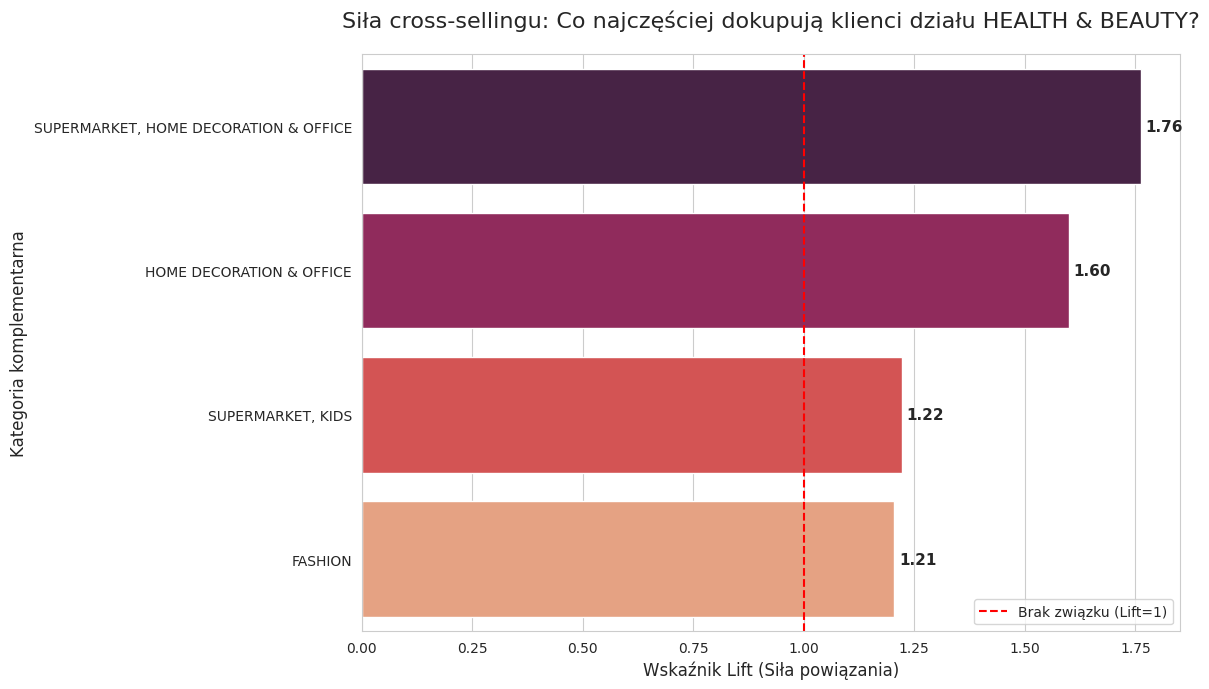

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Przygotowanie danych do wykresu
# Tworzymy czytelną nazwę dla kategorii dokupowanej (consequents)
plot_data = result.copy()
plot_data['Dokupiona Kategoria'] = plot_data['consequents'].apply(lambda x: ', '.join(list(x)))

# 2. Ustawienie stylu wizualizacji
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 3. Tworzenie wykresu słupkowego
bar_plot = sns.barplot(
    data=plot_data, 
    x='lift', 
    y='Dokupiona Kategoria', 
    palette='rocket'
)

# 4. Dodanie etykiet z wartościami na końcach słupków
for p in bar_plot.patches:
    plt.text(
        p.get_width() + 0.01, 
        p.get_y() + p.get_height()/2, 
        f'{p.get_width():.2f}', 
        va='center', 
        fontsize=11, 
        weight='bold'
    )

# 5. Dodanie linii Lift=1 (granica przypadku)
plt.axvline(1, color='red', linestyle='--', linewidth=1.5, label='Brak związku (Lift=1)')

# 6. Opisy
plt.title('Siła cross-sellingu: Co najczęściej dokupują klienci działu HEALTH & BEAUTY?', fontsize=16, pad=20)
plt.xlabel('Wskaźnik Lift (Siła powiązania)', fontsize=12)
plt.ylabel('Kategoria komplementarna', fontsize=12)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [77]:
"""
Wnioski:

>Najsilniejszy związek: Home Decoration & Office

Lift: 1.76 (z Supermarketem) i 1.60 (sam Home Decoration & Office)

 --> Istnieje aż o 76% większe prawdopodobieństwo, że osoba z produktem H&B kupi artykuły do dekoracji domu, niż przeciętny klient 
 
Rekomendacja: Akcje typu "Home Spa" – łączenie świec zapachowych czy tekstyliów domowych z pielęgnacją (zapachy do domów np. Rituals ma spreje zapachowe albo patyczki; dekoracje, miski, wzony itp)

>Segment Rodzinny: Supermarket + Kids

Lift: 1.22.

--> Koszyk "rodzinny" jest wyraźny. Zakup kosmetyków o 22% częściej współwystępuje z zakupami dla dzieci i produktami spożywczymi.
"""

'\nWnioski:\n\n>Najsilniejszy związek: Home Decoration & Office\n\nLift: 1.76 (z Supermarketem) i 1.60 (sam Home Decoration & Office)\n\n --> Istnieje aż o 76% większe prawdopodobieństwo, że osoba z produktem H&B kupi artykuły do dekoracji domu, niż przeciętny klient \n \nRekomendacja: Akcje typu "Home Spa" – łączenie świec zapachowych czy tekstyliów domowych z pielęgnacją (zapachy do domów np. Rituals ma spreje zapachowe albo patyczki; dekoracje, miski, wzony itp)\n\n>Segment Rodzinny: Supermarket + Kids\n\nLift: 1.22.\n\n--> Koszyk "rodzinny" jest wyraźny. Zakup kosmetyków o 22% częściej współwystępuje z zakupami dla dzieci i produktami spożywczymi.\n'

In [78]:
# Spojrzenie sezonowe dla H&B

In [79]:
seasons = df['season'].unique()
seasonal_results = {}

for s in seasons:
    print(f"Analizuję sezon: {s}...")
    # 1. Filtrujemy dane dla danego sezonu
    df_season = df[df['season'] == s]
    
    # 2. Budowa macierzy koszykowej dla sezonu
    basket_season = (df_season.groupby(['purchase_id', 'vertical'])['vertical']
                     .count().unstack().fillna(0)
                     .astype(bool))
    
    # 3. Apriori i Reguły 
    frequent_itemsets = apriori(basket_season, min_support=0.01, use_colnames=True)
    
    if not frequent_itemsets.empty:
        rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
        
        # 4. Filtrowanie (Health & Beauty -> Reszta)
        care_rules = rules[
            (rules['antecedents'].apply(lambda x: len(x) == 1 and 'HEALTH & BEAUTY' in [str(i).upper() for i in x])) &
            (rules['consequents'].apply(lambda x: 'HEALTH & BEAUTY' not in [str(i).upper() for i in x]))
        ]
        
        seasonal_results[s] = care_rules.sort_values(by='lift', ascending=False).head(5)
    else:
        print(f"Brak wystarczających danych dla sezonu: {s}")

# 5. Wyświetlenie wyników
for s in seasonal_results:
    print(f"\n--- TOP RELACJE DLA SEZONU: {s} ---")
    display(seasonal_results[s][['antecedents', 'consequents', 'lift', 'confidence','support',]])

Analizuję sezon: Other...
Analizuję sezon: Winter...
Analizuję sezon: Summer...

--- TOP RELACJE DLA SEZONU: Other ---


,antecedents,consequents,lift,confidence,support
14,(HEALTH & BEAUTY),"(SUPERMARKET, HOME DECORATION & OFFICE)",1.802080,0.055657,0.010694
4,(HEALTH & BEAUTY),(HOME DECORATION & OFFICE),1.679240,0.072934,0.014013
3,(HEALTH & BEAUTY),(FASHION),1.184045,0.078136,0.015013



--- TOP RELACJE DLA SEZONU: Winter ---


,antecedents,consequents,lift,confidence,support
34,(HEALTH & BEAUTY),"(SUPERMARKET, HOME DECORATION & OFFICE)",1.675767,0.050809,0.012688
14,(HEALTH & BEAUTY),(HOME DECORATION & OFFICE),1.412812,0.089725,0.022407
11,(HEALTH & BEAUTY),(FASHION),1.194405,0.091357,0.022814
37,(HEALTH & BEAUTY),"(SUPERMARKET, KIDS)",1.098108,0.054190,0.013533
7,(HEALTH & BEAUTY),(ELECTRONICS),1.060735,0.079959,0.019968



--- TOP RELACJE DLA SEZONU: Summer ---


,antecedents,consequents,lift,confidence,support
14,(HEALTH & BEAUTY),"(SUPERMARKET, HOME DECORATION & OFFICE)",1.893025,0.056968,0.010632
4,(HEALTH & BEAUTY),(HOME DECORATION & OFFICE),1.796815,0.076279,0.014236
3,(HEALTH & BEAUTY),(FASHION),1.204202,0.071049,0.013260


In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tworzymy pustą listę, do której zbierzemy wyniki
plot_data_list = []

for season, df_res in seasonal_results.items():
    # Robimy kopię, żeby nie psuć oryginału
    temp_df = df_res.copy()
    
    # Dodajemy kolumnę z nazwą sezonu
    temp_df['Season'] = season
    
    # Zamieniamy frozenset na zwykły string (np. "HOME DECORATION")
    # Zakładamy, że w consequents jest jeden element, bo filtrowaliśmy health & beauty
    temp_df['Target_Category'] = temp_df['consequents'].apply(lambda x: ', '.join(list(x)))
    
    # Dodajemy do listy
    plot_data_list.append(temp_df)

# Łączymy wszystko w jedną dużą tabelę
combined_df = pd.concat(plot_data_list)

# Sortowanie dla lepszego wyglądu (najwyższy lift na górze)
combined_df = combined_df.sort_values(by=['Season', 'lift'], ascending=[True, False])

print("Dane gotowe do wizualizacji.")

Dane gotowe do wizualizacji.


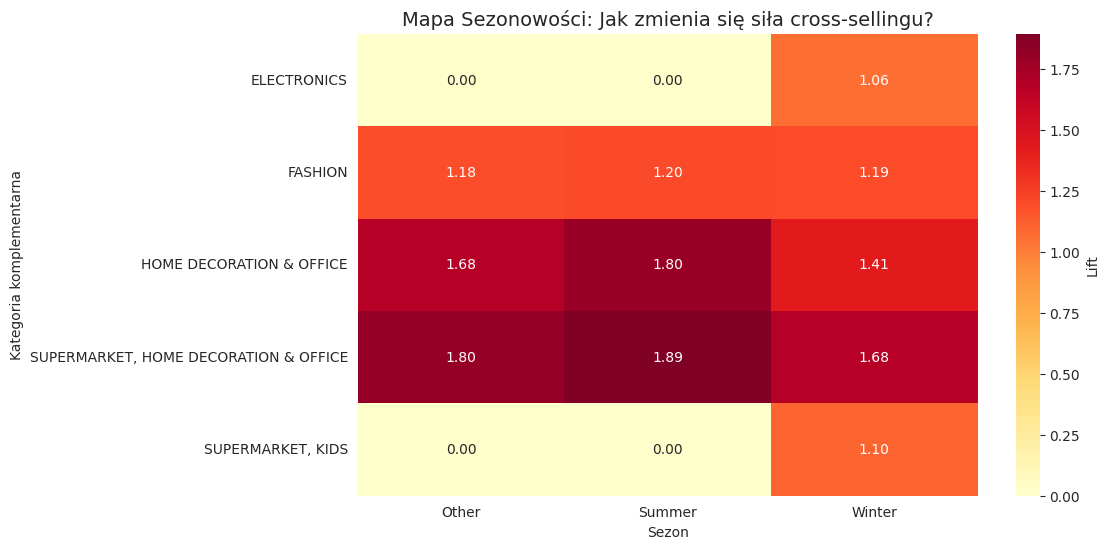

In [81]:
# Tworzymy tabelę przestawną: Wiersze = Kategorie, Kolumny = Sezony, Wartości = Lift
heatmap_data = combined_df.pivot_table(
    index='Target_Category', 
    columns='Season', 
    values='lift'
).fillna(0) # Wypełniamy zerami tam, gdzie nie ma relacji

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data, 
    annot=True,     # Pokaż liczby
    fmt=".2f",      # Format liczb
    cmap="YlOrRd",  # Kolory: Żółty -> Czerwony (im ciemniej, tym silniejszy związek)
    cbar_kws={'label': 'Lift'}
)

plt.title('Mapa Sezonowości: Jak zmienia się siła cross-sellingu?', fontsize=14)
plt.ylabel('Kategoria komplementarna')
plt.xlabel('Sezon')
plt.show()

In [82]:
 """
1. Wnioski Sezonowe
Summer:

>Najsilniejszy Cross-selling: W lecie relacja z Home Decoration & Office (często w pakiecie z Supermarketem) osiąga najwyższy Lift (1.89).

 Może to sugerować zakupy wakacyjne, gdzie klienci w jednym koszyku łączą kosmetyki, artykuły piknikowe (Supermarket) oraz np. akcesoria plażowe lub letnie dekoracje (Home Decor).

Winter:

>Pojawienie się Elektroniki: Tylko w zimie na liście Top 5 pojawia się Electronics (Lift 1.06); 

Efekt okresu świątecznego? Klienci kupują prezenty (elektronika) i przy okazji  kupują zestawy kosmetyczne na prezent.

>Kids, Supermarket  (np. zabawki do użycia zima tj. sanki, jabluszka, ktore dobrze lacza sie z kremami na mrozy)

Other (Wiosna/Jesień):
> Tutaj relacja z domem jest wciąż bardzo silna (Lift 1.68 - 1.80). Kategoria Health & Beauty jest naturalnym towarzyszem zakupów "do domu" niezależnie od pory roku.
"""

'\n1. Wnioski Sezonowe\nSummer:\n\n>Najsilniejszy Cross-selling: W lecie relacja z Home Decoration & Office (często w pakiecie z Supermarketem) osiąga najwyższy Lift (1.89).\n\nMoże to sugerować zakupy wakacyjne, gdzie klienci w jednym koszyku łączą kosmetyki, artykuły piknikowe (Supermarket) oraz np. akcesoria plażowe lub letnie dekoracje (Home Decor).\n\nWinter:\n\n>Pojawienie się Elektroniki: Tylko w zimie na liście Top 5 pojawia się Electronics (Lift 1.06); \n\nEfekt okresu świątecznego? Klienci kupują prezenty (elektronika) i przy okazji  kupują zestawy kosmetyczne na prezent.\n\n>Kids, Supermarket  (np. zabawki do użycia zima tj. sanki, jabluszka, ktore dobrze lacza sie z kremami na mrozy)\n\nOther (Wiosna/Jesień):\n> Tutaj relacja z domem jest wciąż bardzo silna (Lift 1.68 - 1.80). Kategoria Health & Beauty jest naturalnym towarzyszem zakupów "do domu" niezależnie od pory roku.\n'

In [83]:
# Jakie kategorie dla Nivea (inne niz te w ktorej jest Nivea)

In [84]:
import gc
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Funkcja mapująca: Nivea jako brand, reszta jako czysty vertical
nivea_brands = ['NIVEA BABY', 'NIVEA MEN', 'NIVEA', 'NIVEA SUN']

def map_to_pure_categories(row):
    brand_upper = str(row['brand']).upper()
    # Jeśli to Nivea - zwracamy tylko "NIVEA"
    if any(nb in brand_upper for nb in nivea_brands):
        return "NIVEA"
    # Jeśli to nie Nivea - zwracamy tylko kategorię (bez marki)
    return str(row['vertical']).upper()

print("Agregowanie danych (Nivea vs Kategorie)...")
df['analysis_item_pure'] = df.apply(map_to_pure_categories, axis=1)

# 2. Budowa macierzy koszykowej
print("Budowanie macierzy koszykowej...")
basket_pure = (df.groupby(['purchase_id', 'analysis_item_pure'])['analysis_item_pure']
                .count().unstack().fillna(0)
                .astype(bool))

# 3. Generowanie reguł
min_sup = 0.001
# Obniżone wsparcie, aby wyłapać cross-selling 

print(f"Uruchamiam Apriori z min_support={min_sup}...")
frequent_itemsets = apriori(basket_pure, min_support=min_sup, use_colnames=True)

print("Generowanie reguł asocjacyjnych...")
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 4. Filtrowanie
# Antecedents: Tylko "NIVEA"
# Consequents: Wykluczamy "HEALTH & BEAUTY" (kategoria bazowa)
final_nivea_pure = rules[
    rules['antecedents'].apply(lambda x: 'NIVEA' in x and len(x) == 1) & 
    rules['consequents'].apply(lambda x: 'HEALTH & BEAUTY' not in [str(i).upper() for i in x])
]

print(f"Znaleziono {len(final_nivea_pure)} czystych reguł cross-kategorialnych dla Nivea.")

# Wyświetlamy najważniejsze metryki
result = final_nivea_pure[['antecedents', 'consequents', 'support', 'confidence', 'lift','support']].sort_values(by='lift', ascending=False)
display(result)

Agregowanie danych (Nivea vs Kategorie)...
Budowanie macierzy koszykowej...
Uruchamiam Apriori z min_support=0.001...
Generowanie reguł asocjacyjnych...
Znaleziono 5 czystych reguł cross-kategorialnych dla Nivea.


,antecedents,consequents,support,confidence,lift,support
441,(NIVEA),"(FASHION, SUPERMARKET)",0.001395,0.025755,1.256026,0.001395
86,(NIVEA),(HOME DECORATION & OFFICE),0.003085,0.056950,1.134161,0.003085
532,(NIVEA),"(SUPERMARKET, HOME DECORATION & OFFICE)",0.001798,0.033194,1.086570,0.001798
65,(NIVEA),(FASHION),0.003921,0.072385,1.057487,0.003921
34,(NIVEA),(BUILDING & INDUSTRY),0.001350,0.024919,1.033023,0.001350


/var/tmp/ipykernel_7254/1311008561.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


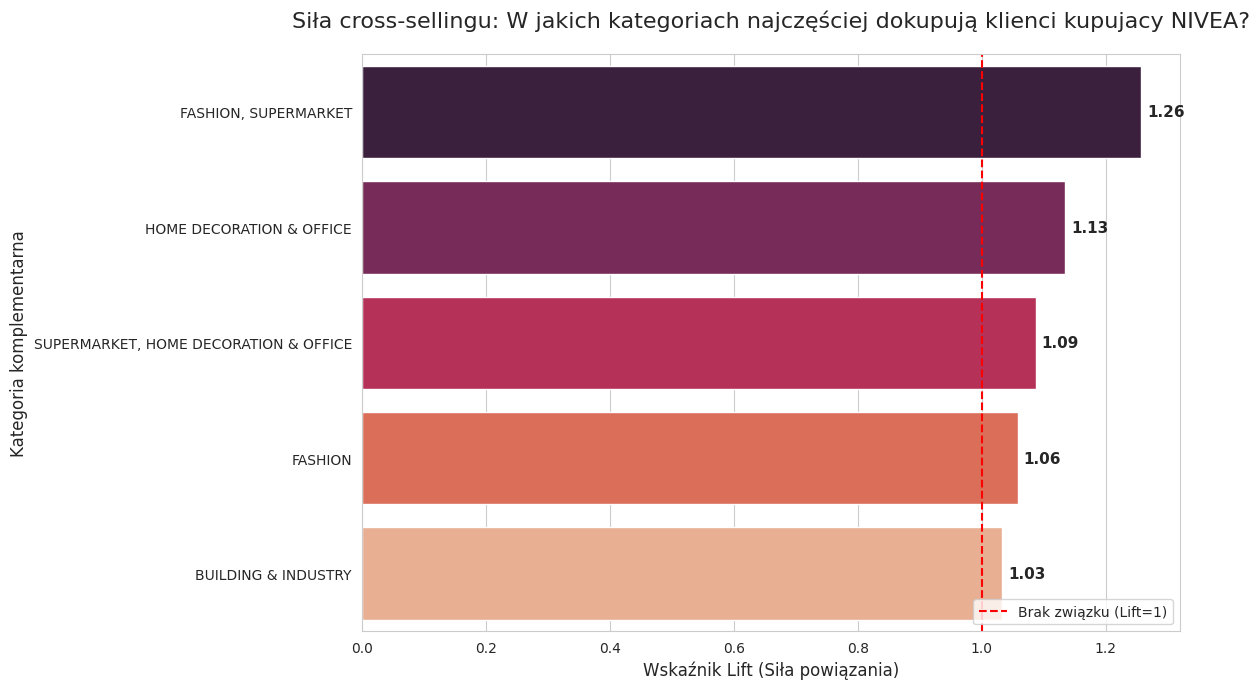

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Przygotowanie danych do wykresu
# Tworzymy czytelną nazwę dla kategorii dokupowanej (consequents)
plot_data = result.copy()
plot_data['Dokupiona Kategoria'] = plot_data['consequents'].apply(lambda x: ', '.join(list(x)))

# 2. Ustawienie stylu wizualizacji
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 3. Tworzenie wykresu słupkowego
bar_plot = sns.barplot(
    data=plot_data, 
    x='lift', 
    y='Dokupiona Kategoria', 
    palette='rocket'
)

# 4. Dodanie etykiet z wartościami na końcach słupków
for p in bar_plot.patches:
    plt.text(
        p.get_width() + 0.01, 
        p.get_y() + p.get_height()/2, 
        f'{p.get_width():.2f}', 
        va='center', 
        fontsize=11, 
        weight='bold'
    )

# 5. Dodanie linii Lift=1 (granica przypadku)
plt.axvline(1, color='red', linestyle='--', linewidth=1.5, label='Brak związku (Lift=1)')

# 6. Opisy
plt.title('Siła cross-sellingu: W jakich kategoriach najczęściej dokupują klienci kupujacy NIVEA?', fontsize=16, pad=20)
plt.xlabel('Wskaźnik Lift (Siła powiązania)', fontsize=12)
plt.ylabel('Kategoria komplementarna', fontsize=12)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [86]:
"""
1. Kluczowe powiązania
>Fashion + Supermarket- najsilniejsza relacja w zestawieniu. Klient kupujący Nivea o 26% częściej niż przeciętny klient ma w koszyku jednocześnie produkty modowe i spożywcze.

Lift: 1.26 (Reguła 441) oraz 1.06 (Reguła 65).

Wniosek: Klient, który dba o wygląd kompleksowo (kosmetyki + ubrania). 
Kampanie np. "get ready with me" łączącymi pielęgnację z trendami modowymi.

>Home Decoration & Office

Lift: 1.13 (Reguła 86) oraz 1.09 (Reguła 532).

Wniosek: Produkty Nivea (szczególnie kremy do rąk czy produkty typu "care") mogą być promowane jako element domowego kącika do pracy.

>Building & Industry - obecność specyficznego segmentu klientów – prawdopodobnie mężczyzn wykonujących prace techniczne/remontowe, którzy przy okazji zakupów "budowlanych" sięgają po produkty Nivea (prawdopodobnie linię NIVEA MEN). Jakies produkty 3w1?

2. Co mówią liczby?
Support: Najwyższe wsparcie ma relacja z Fashion (0.0039). najpopularniejsza kombinacja w danych == największe wolumenowo promocje

Confidence: Najwyższa ufność występuje przy Home Decoration & Office (0.057). 6 na 100 osób kupujących Nivea, dokłada do koszyka coś z działu dom/biuro --> pole do cross sellingu

3. Rekomendacje:

Cross-Marketing z kategorią Fashion: Wspólne akcje lojalnościowe (np. kup Nivea, odbierz kupon na odzież lub odwrotnie). Klient tych dwóch światów to ta sama osoba.

Ekspozycja "Home Comfort": Umieszczenie produktów pielęgnacyjnych Nivea w strefach "Home Office" lub przy dekoracjach, promując je jako produkty poprawiające komfort pracy w domu.

Targetowanie linii męskiej: Skoro pojawia się kategoria Building & Industry, warto sprawdzić, czy linia Nivea Men nie powinna mieć dodatkowej ekspozycji w pobliżu narzędzi lub działów technicznych, szczególnie w okresach wzmożonych remontów.
"""

'\n1. Kluczowe powiązania\n>Fashion + Supermarket- najsilniejsza relacja w zestawieniu. Klient kupujący Nivea o 26% częściej niż przeciętny klient ma w koszyku jednocześnie produkty modowe i spożywcze.\n\nLift: 1.26 (Reguła 441) oraz 1.06 (Reguła 65).\n\nWniosek: Klient, który dba o wygląd kompleksowo (kosmetyki + ubrania). \nKampanie np. "get ready with me" łączącymi pielęgnację z trendami modowymi.\n\n>Home Decoration & Office\n\nLift: 1.13 (Reguła 86) oraz 1.09 (Reguła 532).\n\nWniosek: Produkty Nivea (szczególnie kremy do rąk czy produkty typu "care") mogą być promowane jako element domowego kącika do pracy.\n\n>Building & Industry - obecność specyficznego segmentu klientów – prawdopodobnie mężczyzn wykonujących prace techniczne/remontowe, którzy przy okazji zakupów "budowlanych" sięgają po produkty Nivea (prawdopodobnie linię NIVEA MEN). Jakies produkty 3w1?\n\n2. Co mówią liczby?\nSupport: Najwyższe wsparcie ma relacja z Fashion (0.0039). najpopularniejsza kombinacja w danych == 

In [87]:
#DANE Z SEZONEM
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Przygotowanie kolumny agregującej (NIVEA vs Reszta Kategorii)
nivea_brands = ['NIVEA BABY', 'NIVEA MEN', 'NIVEA', 'NIVEA SUN']

def map_to_pure_categories(row):
    brand_upper = str(row['brand']).upper()
    if any(nb in brand_upper for nb in nivea_brands):
        return "NIVEA"
    return str(row['vertical']).upper()

df['analysis_item_pure'] = df.apply(map_to_pure_categories, axis=1)

# 2. Pętla po sezonach
seasons = df['season'].unique()
seasonal_nivea_results = {}

print("Rozpoczynam analizę sezonową dla marki NIVEA...")

for s in seasons:
    # Filtrowanie danych pod sezon
    df_season = df[df['season'] == s]
    
    # Budowa macierzy koszykowej
    basket_pure = (df_season.groupby(['purchase_id', 'analysis_item_pure'])['analysis_item_pure']
                    .count().unstack().fillna(0)
                    .astype(bool))
    
    # Generowanie reguł (obniżony support ze względu na podział danych na sezony)
    frequent_itemsets = apriori(basket_pure, min_support=0.001, use_colnames=True)
    
    if not frequent_itemsets.empty:
        rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
        
        # Filtrowanie: NIVEA -> Inna Kategoria (poza Health & Beauty)
        nivea_rules = rules[
            (rules['antecedents'].apply(lambda x: 'NIVEA' in x and len(x) == 1)) & 
            (rules['consequents'].apply(lambda x: 'HEALTH & BEAUTY' not in [str(i).upper() for i in x]))
        ]
        
        seasonal_nivea_results[s] = nivea_rules.sort_values(by='lift', ascending=False).head(10)
    else:
        print(f"Brak częstych zbiorów dla sezonu: {s}")

# 3. Wyświetlenie wyników
for s in seasonal_nivea_results:
    print(f"\n{'='*20} SEZON: {s.upper()} {'='*20}")
    if not seasonal_nivea_results[s].empty:
        display(seasonal_nivea_results[s][['antecedents', 'consequents', 'support', 'confidence', 'lift']])
    else:
        print("Brak istotnych reguł cross-kategorialnych w tym sezonie.")

Rozpoczynam analizę sezonową dla marki NIVEA...

==================== SEZON: OTHER ====================


,antecedents,consequents,support,confidence,lift
72,(NIVEA),(HOME DECORATION & OFFICE),0.002077,0.051516,1.186107
352,(NIVEA),"(SUPERMARKET, HOME DECORATION & OFFICE)",0.001378,0.034173,1.106446
30,(NIVEA),(BUILDING & INDUSTRY),0.001005,0.024923,1.091066
53,(NIVEA),(FASHION),0.002724,0.067575,1.024001



==================== SEZON: WINTER ====================


,antecedents,consequents,support,confidence,lift
609,(NIVEA),"(FASHION, SUPERMARKET)",0.001827,0.028692,1.368077
694,(NIVEA),"(SUPERMARKET, HOME DECORATION & OFFICE)",0.002242,0.035208,1.162060
32,(NIVEA),(BUILDING & INDUSTRY),0.001834,0.028807,1.099203
84,(NIVEA),(HOME DECORATION & OFFICE),0.004324,0.067901,1.069180
65,(NIVEA),(FASHION),0.005176,0.081276,1.062602
92,(NIVEA),(SPORT & LEISURE),0.001150,0.018061,1.034205



==================== SEZON: SUMMER ====================


,antecedents,consequents,support,confidence,lift
78,(NIVEA),(SPORT & LEISURE),0.001502,0.020088,1.555495
329,(NIVEA),"(FASHION, SUPERMARKET)",0.001727,0.023102,1.237639
58,(NIVEA),(GARDEN),0.002147,0.028726,1.209196
49,(NIVEA),(FASHION),0.004805,0.064283,1.089520
70,(NIVEA),(HOME DECORATION & OFFICE),0.003454,0.046203,1.088352


In [ ]:
"""
☀️ LATO: Najwyższy potencjał wzrostu
Lato to czas, gdy NIVEA notuje najwyższe wskaźniki przyciągania (Lift) w nietypowych kategoriach.

Kategorie Partnerskie: SPORT & LEISURE (Lift 1.56!) oraz GARDEN (Lift 1.21).

Insight: Klient łączy NIVEA z aktywnością na zewnątrz.

Rekomendacja: Cross-merchandising – pakiety z Nivea Sun i antyperspirantami przy sprzęcie sportowym, basenach ogrodowych i akcesoriach grillowych.

❄️ ZIMA: Ochrona i Styl
Kategorie Partnerskie: FASHION, SUPERMARKET (Lift 1.37) oraz BUILDING & INDUSTRY (Lift 1.10).

Insight: Ochrona przed mrozem łączy się z zakupem ciepłej odzieży oraz pracami technicznymi (ochrona dłoni przy pracy w zimnie).

Rekomendacja:
- Promocje łączone: np. "Kup kurtkę/czapkę – odbierz 20% na krem ochronny NIVEA".
- Ekspozycja męska: NIVEA MEN przy dziale technicznym/majsterkowania (produkty do rąk i twarzy).

🍂 WIOSNA/JESIEŃ: Powrót do Biura i Domu
W okresach przejściowych marka wraca do silnego trendu ogólno kategorialnego (wspólnego z H&B).

Kategorie Partnerskie: HOME DECORATION & OFFICE (Lift 1.19).

Insight: Czas porządków, odświeżania wnętrz i pracy biurowej.

Rekomendacja:
- Kampania "Office Skin": Promocja kremów do rąk i twarzy jako niezbędnika na biurku (ochrona przed suchym powietrzem biurowym/klimatyzacją).
- Zestawy: Świece zapachowe + Pielęgnacja (rytuał domowy).

🎯 STRATEGIA BUDŻETOWA - Macierz Szans (Support vs. Confidence vs. Lift)

Budżet Marketingowy (Mass Scale): 
Należy inwestować w łączenie Nivea z kategorią Fashion. Mimo umiarkowanego wskaźnika Lift (1.06 – 1.26), kategoria ta generuje największy wolumen wspólnych transakcji (najwyższy Support). To najbezpieczniejszy obszar do budowania masowego zasięgu w mediach.

Siły Sprzedażowe (Conversion & Impulse): 
Skupić się na dwóch obszarach:
1. Dział Home Decoration & Office: Pewna konwersja przez cały rok. Stabilny Lift 1.13 – 1.19 oznacza, że klient naturalnie łączy te produkty, wystarczy mu je podać.
2. Dział Sport (LATO): Najsilniejszy impuls zakupowy. Rekordowy Lift 1.56 w sezonie letnim oznacza, że pokazywanie Nivea przy sprzęcie sportowym zadziała jak magnes, nawet bez drogiej reklamy.
3. Dział Garden (LATO): Wysoki Lift na poziomie 1.21 sugeruje, że przy sezonie letnim istnieje silne powiązanie z produktami do ogrodu a tymi z marki Nivea.
"""

'\nSUMMER – Sezon Aktywności i Ogrodu \n\n>Sport & Leisure (Lift 1.56): najwyższy Lift! Latem związek Nivea ze sportem jest o 56% silniejszy niż wynikałoby to z przypadku.\n\nWniosek: Nivea Sun lub Nivea Men powinny być promowane przy bidonach i sprzęcie sportowym (ochrona przez slonce)\n\n>Garden (Lift 1.21): \n\nWniosek: Prace w ogrodzie to ekspozycja na słońce i brud – idealny moment na promocję kremów ochronnych i żeli pod prysznic w pobliżu narzędzi ogrodowych.\n\nWINTER – Koszyk Prezentowo-Modowy\nZima zmienia priorytety klienta Nivea na dom i wygląd.\n\n>Fashion + Supermarket (Lift 1.37): Znacznie silniejszy niż w innych sezonach.\n\nWniosek: To sugeruje zakupy odzieżowe (ciepłe ubrania?) łączone z pielęgnacją ochronną (bo mrozy, przesuszenia itp)\n\n>Building & Industry (Lift 1.10): Co ciekawe, zimą to powiązanie jest silniejsze niż w innych okresach.\n\nWniosek: Może to wynikać z faktu, że zimą skóra dłoni osób pracujących fizycznie wymaga większej ochrony, bo oprocz pracy fiz

In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# KROK 1: Konwersja wyników ze słownika do jednej tabeli
plot_data_list = []

for season, df_res in seasonal_nivea_results.items():
    if not df_res.empty:
        # Robimy kopię, żeby nie modyfikować oryginału
        temp_df = df_res.copy()
        temp_df['Season'] = season
        
        # Zamieniamy techniczny 'frozenset' na czytelną nazwę (np. "FASHION, SUPERMARKET")
        temp_df['Category_Name'] = temp_df['consequents'].apply(lambda x: ', '.join(list(x)))
        
        plot_data_list.append(temp_df)

if plot_data_list:
    combined_nivea_df = pd.concat(plot_data_list)
    print("Dane zostały połączone i są gotowe do wykresu.")
else:
    print("Brak danych do wizualizacji.")

Dane zostały połączone i są gotowe do wykresu.


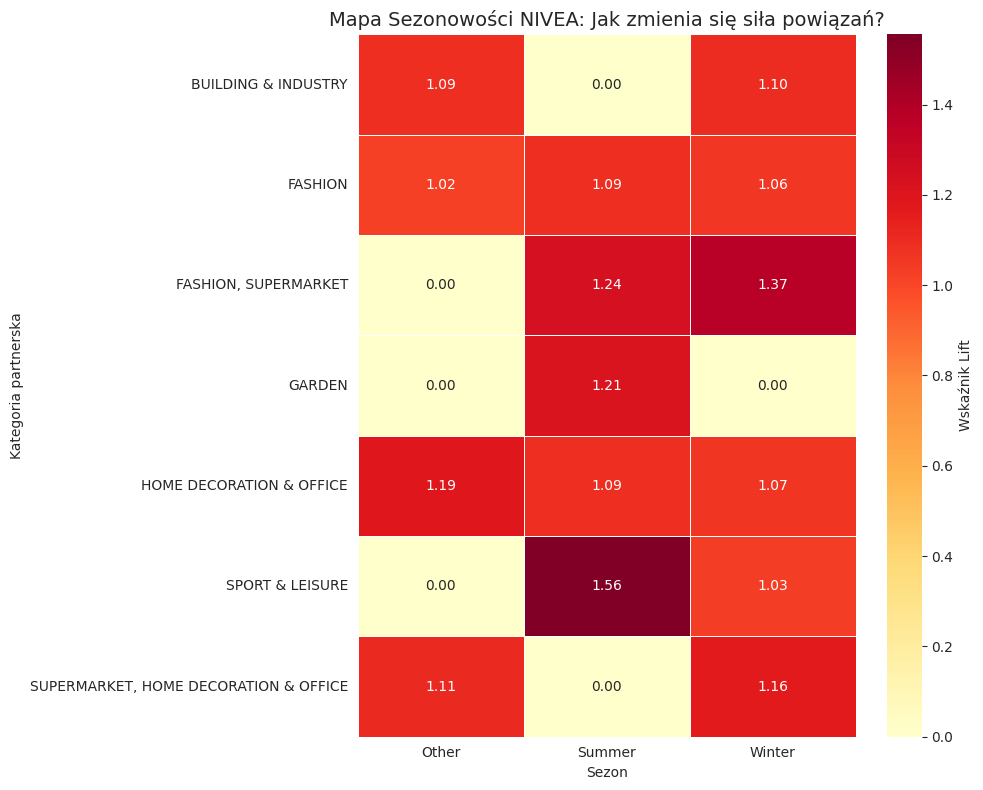

In [90]:
# Tworzymy tabelę przestawną (Macierz: Kategorie x Sezony)
heatmap_matrix = combined_nivea_df.pivot_table(
    index='Category_Name', 
    columns='Season', 
    values='lift'
).fillna(0) # Wypełniamy zerami tam, gdzie nie ma reguły

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_matrix, 
    annot=True,     # Wyświetl wartości liczbowe
    fmt=".2f",      # Formatowanie do 2 miejsc po przecinku
    cmap="YlOrRd",  # Kolory od żółtego (słabe) do czerwonego (mocne)
    linewidths=.5,
    cbar_kws={'label': 'Wskaźnik Lift'}
)

plt.title('Mapa Sezonowości NIVEA: Jak zmienia się siła powiązań?', fontsize=14)
plt.ylabel('Kategoria partnerska')
plt.xlabel('Sezon')
plt.tight_layout()
plt.show()

In [91]:
!pip install adjustText

Looking in indexes: https://artifactory.allegrogroup.com/artifactory/api/pypi/pypi.python.org/simple, https://artifactory.allegrogroup.com/artifactory/api/pypi/pypi-local/simple


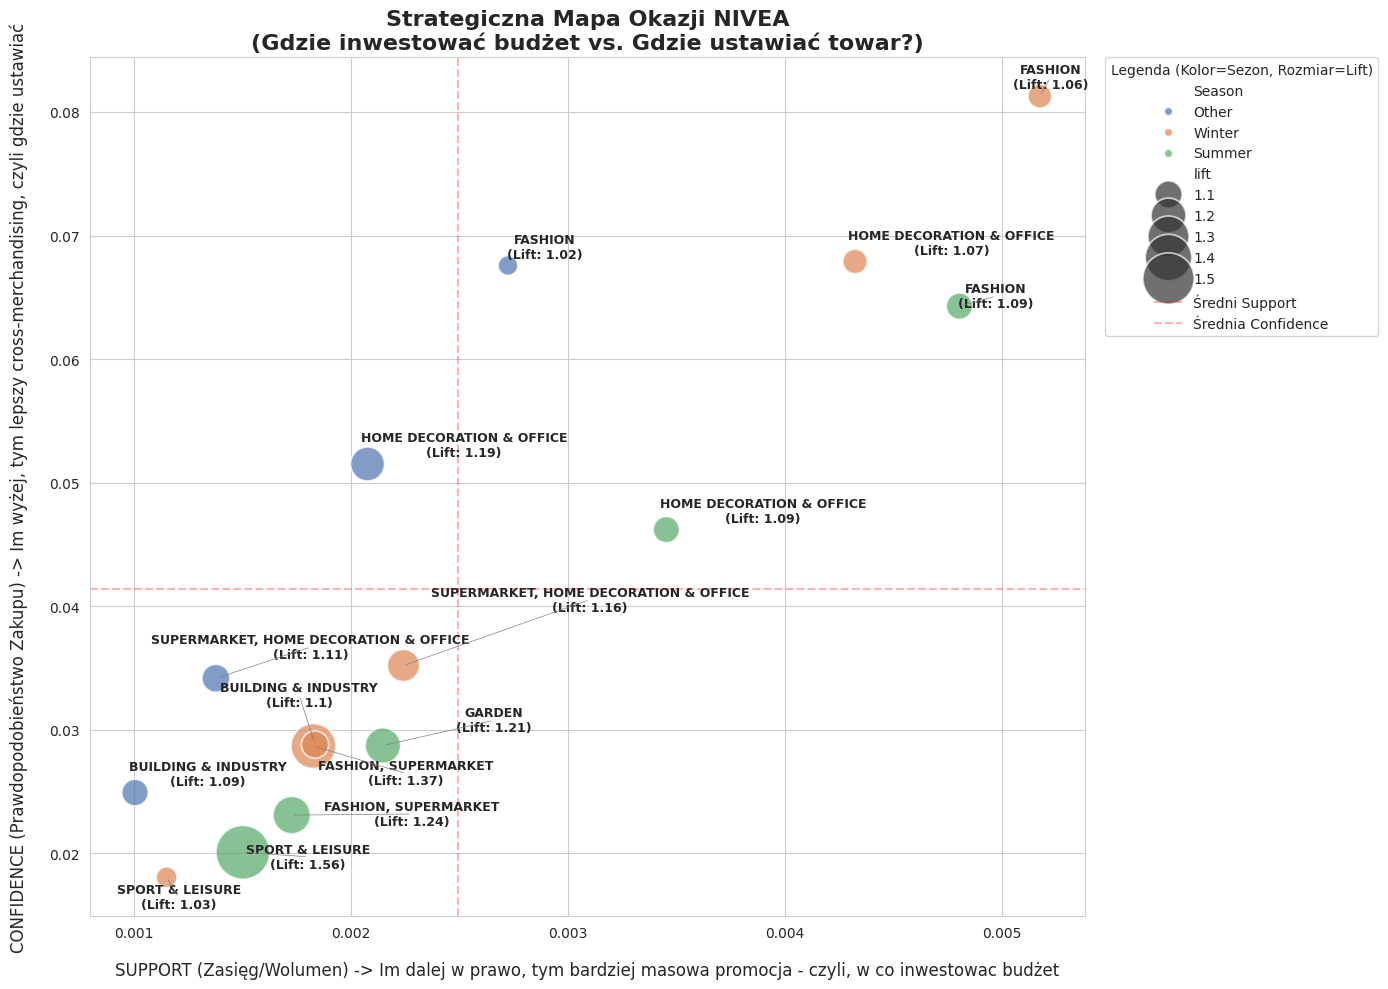

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# Funkcja do poprawiania tekstu
from adjustText import adjust_text

plt.figure(figsize=(14, 10)) 
sns.set_style("whitegrid")

# 1. Rysujemy Scatter Plot
scatter = sns.scatterplot(
    data=combined_nivea_df,
    x="support",
    y="confidence",
    size="lift",       # Rozmiar bąbelka = Siła relacji (Lift)
    hue="Season",      # Kolor = Sezon
    sizes=(200, 1500), # Większe bąbelki są czytelniejsze
    alpha=0.7,
    palette="deep"     # Wyraźna paleta kolorów
)

# 2. Przygotowanie etykiet (zbieramy je do listy)
texts = []
for i in range(combined_nivea_df.shape[0]):
    # Dodajemy każdy tekst do listy 'texts'
    texts.append(plt.text(
        x=combined_nivea_df.support.iloc[i],
        y=combined_nivea_df.confidence.iloc[i],
        s=combined_nivea_df.Category_Name.iloc[i] + "\n(Lift: " + str(round(combined_nivea_df.lift.iloc[i], 2)) + ")", # Wartosc Lift do opisu
        fontdict={'weight': 'bold', 'size': 9}
    ))

# 3. Automatyczne dopasowanie pozycji tekstu
# force_text - jak mocno ma odpychać etykiety od siebie
# expand_points - jak bardzo ma omijać same bąbelki
adjust_text(texts, 
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5), # Cienkie linie łączące
            force_text=(0.5, 1.5),
            expand_points=(1.2, 1.2)
           )

# 4. Linie pomocnicze (średnie wartości) 
avg_support = combined_nivea_df['support'].mean()
avg_conf = combined_nivea_df['confidence'].mean()

plt.axvline(x=avg_support, color='red', linestyle='--', alpha=0.3, label='Średni Support')
plt.axhline(y=avg_conf, color='red', linestyle='--', alpha=0.3, label='Średnia Confidence')

# 5. Opisy osi i tytuł
plt.title('Strategiczna Mapa Okazji NIVEA\n(Gdzie inwestować budżet vs. Gdzie ustawiać towar?)', fontsize=16, weight='bold')
plt.xlabel('SUPPORT (Zasięg/Wolumen) -> Im dalej w prawo, tym bardziej masowa promocja - czyli, w co inwestowac budżet', fontsize=12, labelpad=15)
plt.ylabel('CONFIDENCE (Prawdopodobieństwo Zakupu) -> Im wyżej, tym lepszy cross-merchandising, czyli gdzie ustawiać', fontsize=12, labelpad=15)

# Legenda poza wykresem
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., title="Legenda (Kolor=Sezon, Rozmiar=Lift)")

plt.tight_layout()
plt.show()